In [3]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from _utils._utils_spline import eval_spline_basis_equispaced_numeric
from _run._run_generate_distortion_data import max_ratio_cd, max_ratio_cond, plot_max_ratio_cond, plot_max_ratio_cond_implementation

---
## Centring + Dropping

In [4]:
data = pickle.load(open(os.path.join("../data", "data12345newf1.pkl"), "rb"))

In [5]:
replication = 0
key = ('f1', 0.5)
x, y = data[key][replication]
x_order = np.argsort(x)
x, y = x[x_order], y[x_order]

In [6]:
degree = 3
x_vals = x.copy()
x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 100)
num_knots = 5
B = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_vals)['B']
B_plot = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot)['B']
n, k = B.shape

In [7]:
v = - max_ratio_cd(k)
print(v)

[[-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [-0.11785113]
 [ 0.94280904]]


This maximising weight vector is the same as **e_(-1)** with a constant shift, so it maps to the last basis function with a shift. Note that this shape does not depend on the x data distribution (exept for the min and max values that determine the range), but only on the number of internal knots chosen.

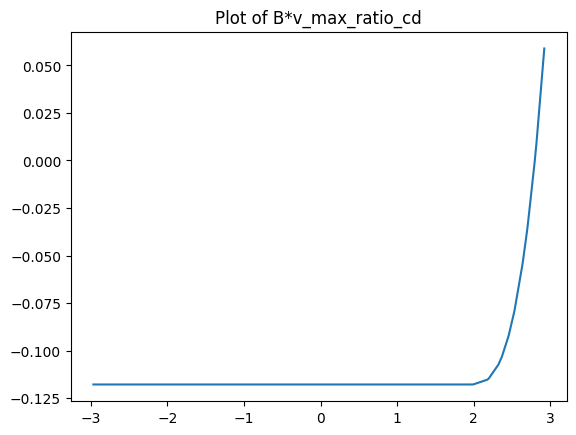

In [8]:
plt.plot(x_vals, B@v)
plt.title("Plot of B*v_max_ratio_cd")
plt.show()

This is the last basis function.

---
# Conditioning

In [9]:
###
data_dict_path = os.path.join("../data", "data_dictQ.pkl")
with open(data_dict_path, "rb") as f:
    data_dict = pickle.load(f)

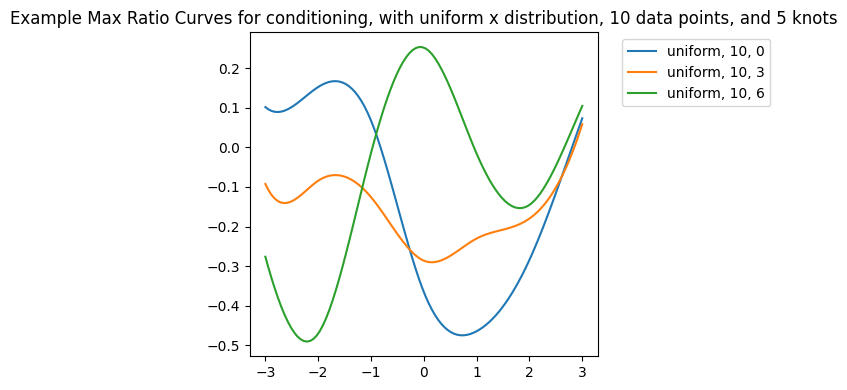

In [10]:
# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [10]
replication_l = [0, 3, 6]
dist = ['uniform']
num_k = 5

fig, ax = plot_max_ratio_cond(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

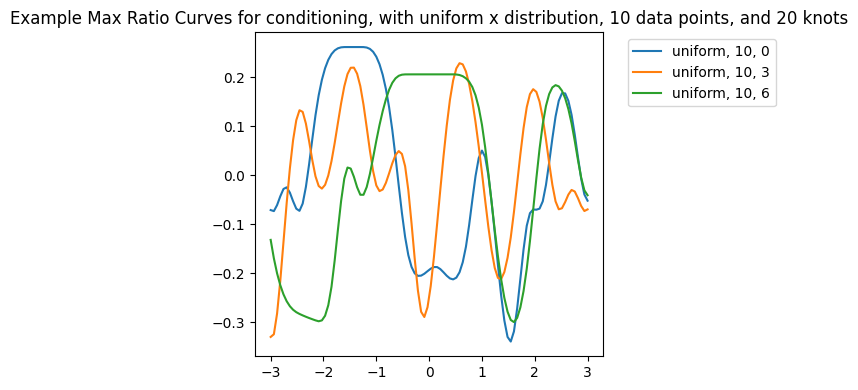

In [11]:
# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [10]
replication_l = [0, 3, 6]
dist = ['uniform']
num_k = 20

fig, ax = plot_max_ratio_cond(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

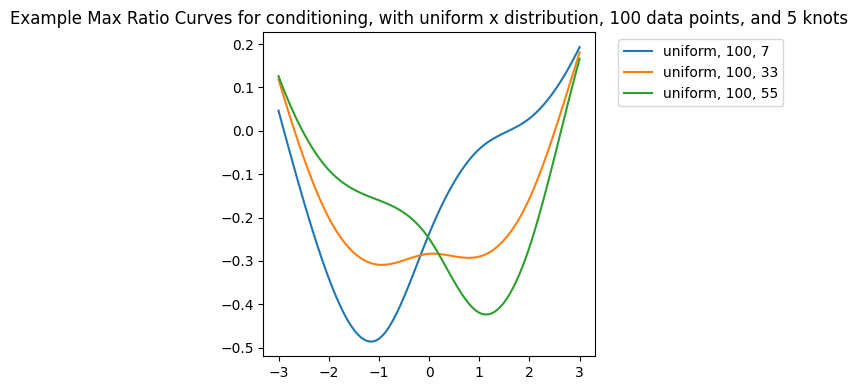

In [12]:
# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [100]
replication_l = [7, 33, 55]
dist = ['uniform']
num_k = 5

fig, ax = plot_max_ratio_cond(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

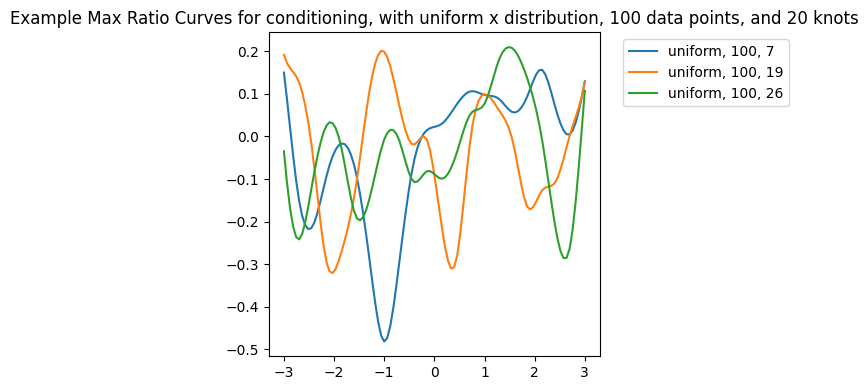

In [13]:
# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [100]
replication_l = [7, 19, 26]
dist = ['uniform']
num_k = 20

fig, ax = plot_max_ratio_cond(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

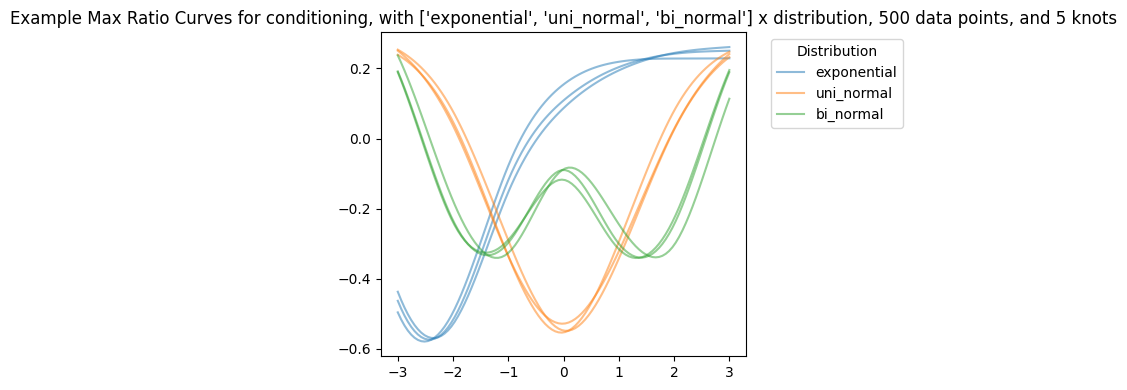

In [14]:
# with more data points, the difference between x distributions is clearer
n_l = [500]
replication_l = [0, 1, 2]
dist = ['exponential', 'uni_normal', 'bi_normal']
num_k = 5

fig, ax = plot_max_ratio_cond_implementation(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

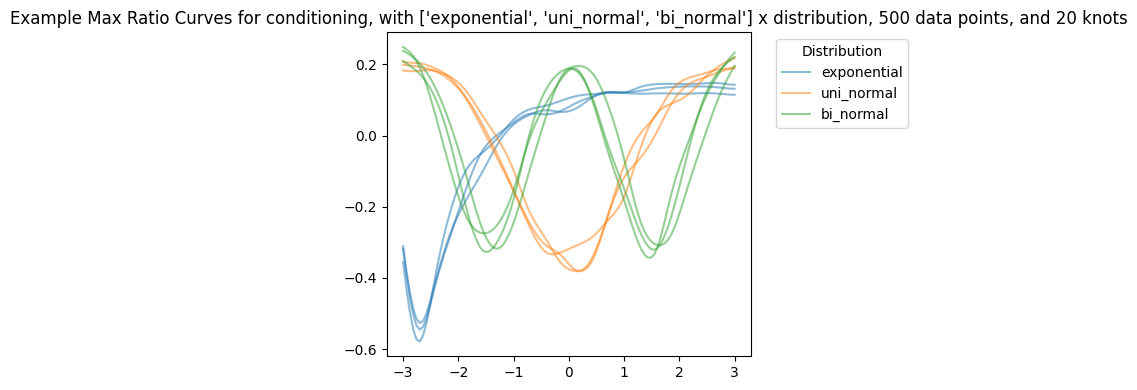

In [15]:
# with more data points, the difference between x distributions is clearer
n_l = [500]
replication_l = [0, 1, 2]
dist = ['exponential', 'uni_normal', 'bi_normal']
num_k = 20

fig, ax = plot_max_ratio_cond_implementation(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()